In [1]:
# Install Libraries

import sys
!{sys.executable} -m pip install matplotlib seaborn scipy openpyxl scikit-learn imbalanced-learn xgboost --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("Libraries loaded")

Libraries loaded


In [3]:
# Paths 

COVID_PATH   = '/workspaces/group-project-inferra/Data/AUS_COVID19_biweekly.csv'
RSV_PATH     = '/workspaces/group-project-inferra/Data/AUS_rsv.xlsx'
MEASLES_PATH = '/workspaces/group-project-inferra/Data/AUS_measles.xlsx'
OUTPUT_PATH  = '/workspaces/group-project-inferra/Data/features_covid_aus.csv'
print("Paths set")

Paths set


In [4]:
# Load Raw Data

# AUS_COVID19_biweekly.csv is already Australia-only 
aus_covid = pd.read_csv(COVID_PATH, parse_dates=['Date_reported'])
aus_covid = aus_covid.sort_values('Date_reported').reset_index(drop=True)

rsv_wide = pd.read_excel(RSV_PATH)
msl_wide = pd.read_excel(MEASLES_PATH)

print(f"Australia COVID rows : {len(aus_covid)}")
print(f"Date range : {aus_covid['Date_reported'].min().date()} → {aus_covid['Date_reported'].max().date()}")
display(aus_covid.head(3))


Australia COVID rows : 158
Date range : 2020-01-12 → 2026-01-18


,Date_start,Date_reported,Biweek_label,Biweek_index,Country,Country_code,WHO_region,New_cases,New_deaths,Cumulative_cases,Cumulative_deaths,Year,Week_num,flag_incomplete_biweek
0,2020-01-05,2020-01-12,2020-01-05 to 2020-01-12,1,Australia,AU,WPRO,0,0,0,0,2020,2,0
1,2020-01-19,2020-01-26,2020-01-19 to 2020-01-26,2,Australia,AU,WPRO,4,0,4,0,2020,4,0
2,2020-02-02,2020-02-09,2020-02-02 to 2020-02-09,3,Australia,AU,WPRO,11,0,15,0,2020,6,0


In [5]:
# NNDSS Wide → Long Format

def nndss_to_long(wide_df):
    """Melt NNDSS wide table into long format with real dates."""
    long = wide_df.melt(id_vars='Disease_Name', var_name='Period', value_name='Cases')

    def fn_to_date(period):
        parts       = period.split('_')
        fn_num      = int(parts[0][2:])
        year        = int(parts[1])
        day_of_year = (fn_num - 1) * 14 + 1
        return pd.Timestamp(f'{year}-01-01') + pd.Timedelta(days=day_of_year - 1)

    long['Date']  = long['Period'].apply(fn_to_date)
    long['Cases'] = pd.to_numeric(long['Cases'], errors='coerce').fillna(0)
    return long.sort_values('Date').reset_index(drop=True)

nndss_long = nndss_to_long(nndss_wide)

FOCUS_DISEASES = [
    'Influenza (laboratory confirmed)',
    'Respiratory syncytial virus (RSV)',
    'Measles', 'Pertussis', 'COVID-19',
]
focus_long = nndss_long[nndss_long['Disease_Name'].isin(FOCUS_DISEASES)].copy()
print(f"NNDSS long format | Focus rows: {len(focus_long)}")

NameError: name 'nndss_wide' is not defined

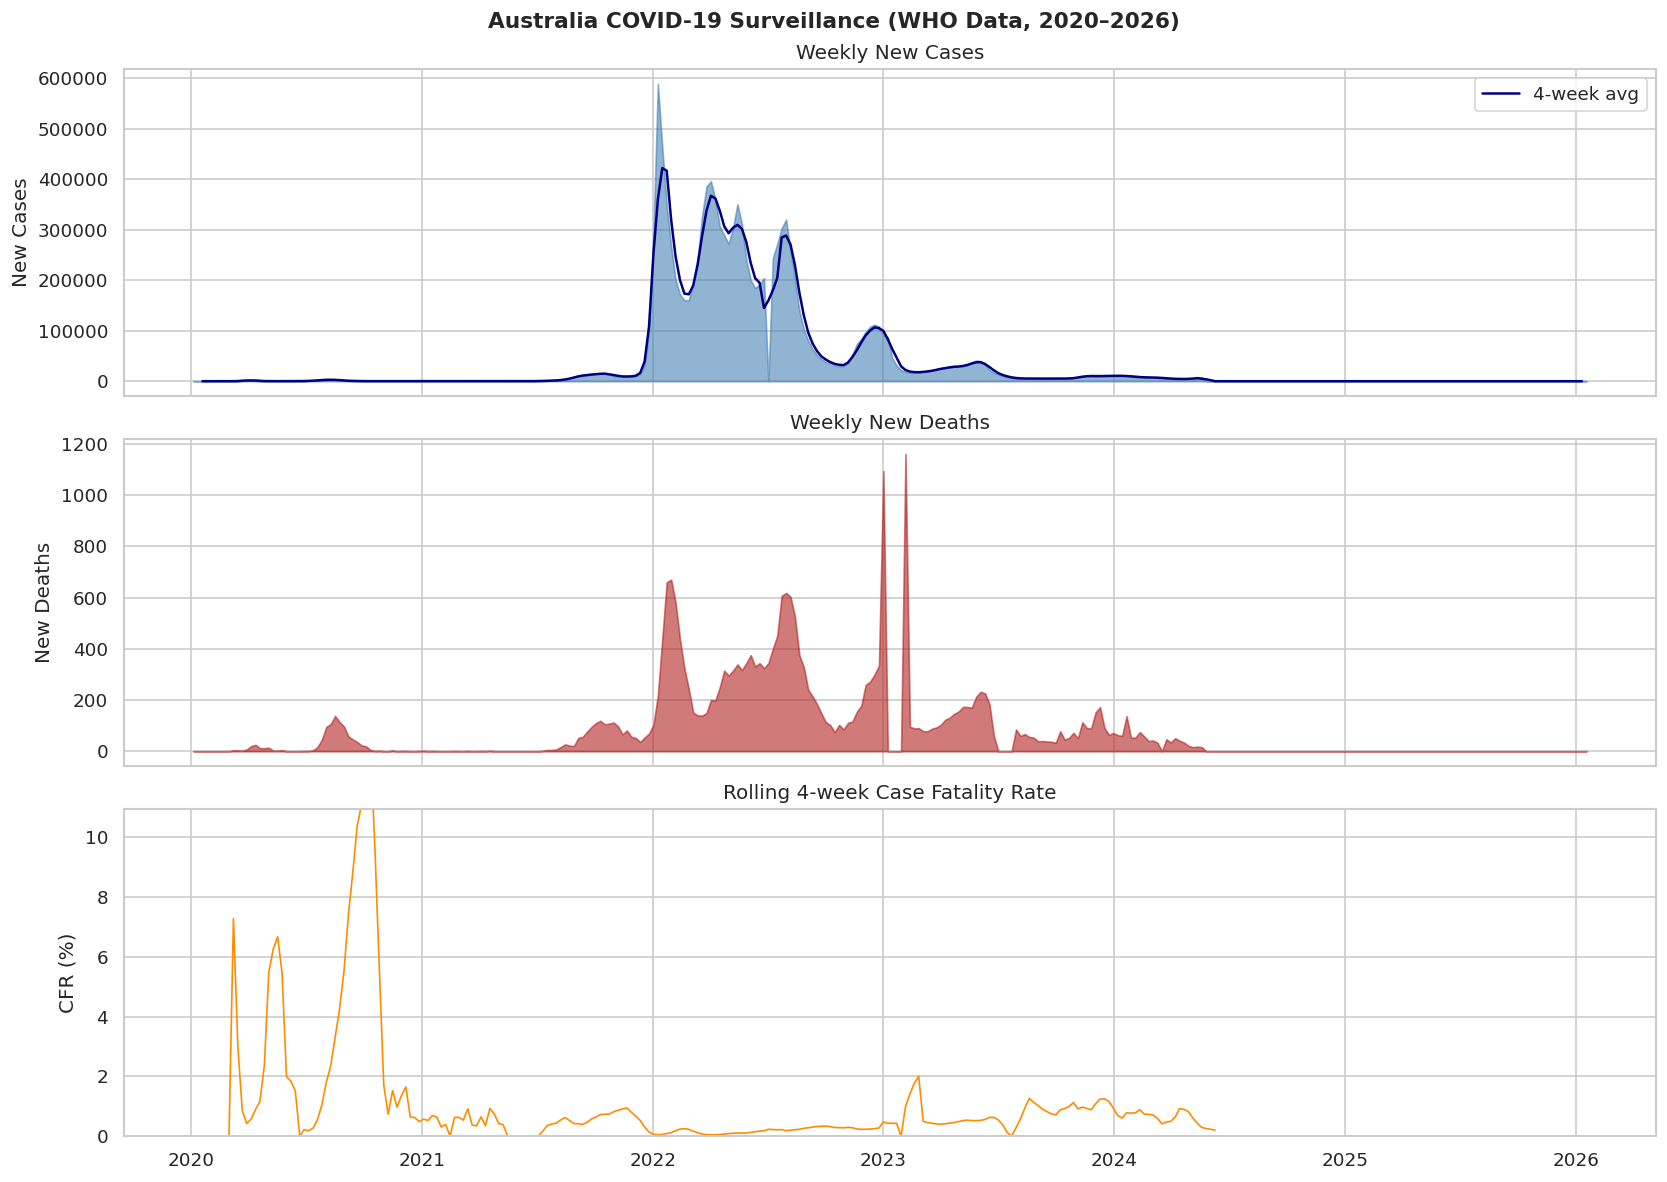

Peak week : 2022-01-09  (588,813 cases)


In [ ]:
# EDA: COVID Timeline

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Australia COVID-19 Surveillance (WHO Data, 2020–2026)",
             fontsize=13, fontweight='bold')

axes[0].fill_between(aus_covid['Date_reported'], aus_covid['New_cases'],
                     alpha=0.6, color='steelblue')
axes[0].plot(aus_covid['Date_reported'],
             aus_covid['New_cases'].rolling(4, center=True).mean(),
             color='navy', linewidth=1.5, label='4-week avg')
axes[0].set_ylabel('New Cases')
axes[0].set_title('Weekly New Cases')
axes[0].legend()

axes[1].fill_between(aus_covid['Date_reported'], aus_covid['New_deaths'],
                     alpha=0.6, color='firebrick')
axes[1].set_ylabel('New Deaths')
axes[1].set_title('Weekly New Deaths')

cfr = (aus_covid['New_deaths'].rolling(4).sum() /
       aus_covid['New_cases'].rolling(4).sum().replace(0, np.nan) * 100)
axes[2].plot(aus_covid['Date_reported'], cfr, color='darkorange', linewidth=1)
axes[2].set_ylabel('CFR (%)')
axes[2].set_title('Rolling 4-week Case Fatality Rate')
axes[2].set_ylim(0, cfr.quantile(0.97) * 1.5)

plt.tight_layout()
plt.show()

print(f"Peak week : {aus_covid.loc[aus_covid['New_cases'].idxmax(), 'Date_reported'].date()}"
      f"  ({aus_covid['New_cases'].max():,} cases)")

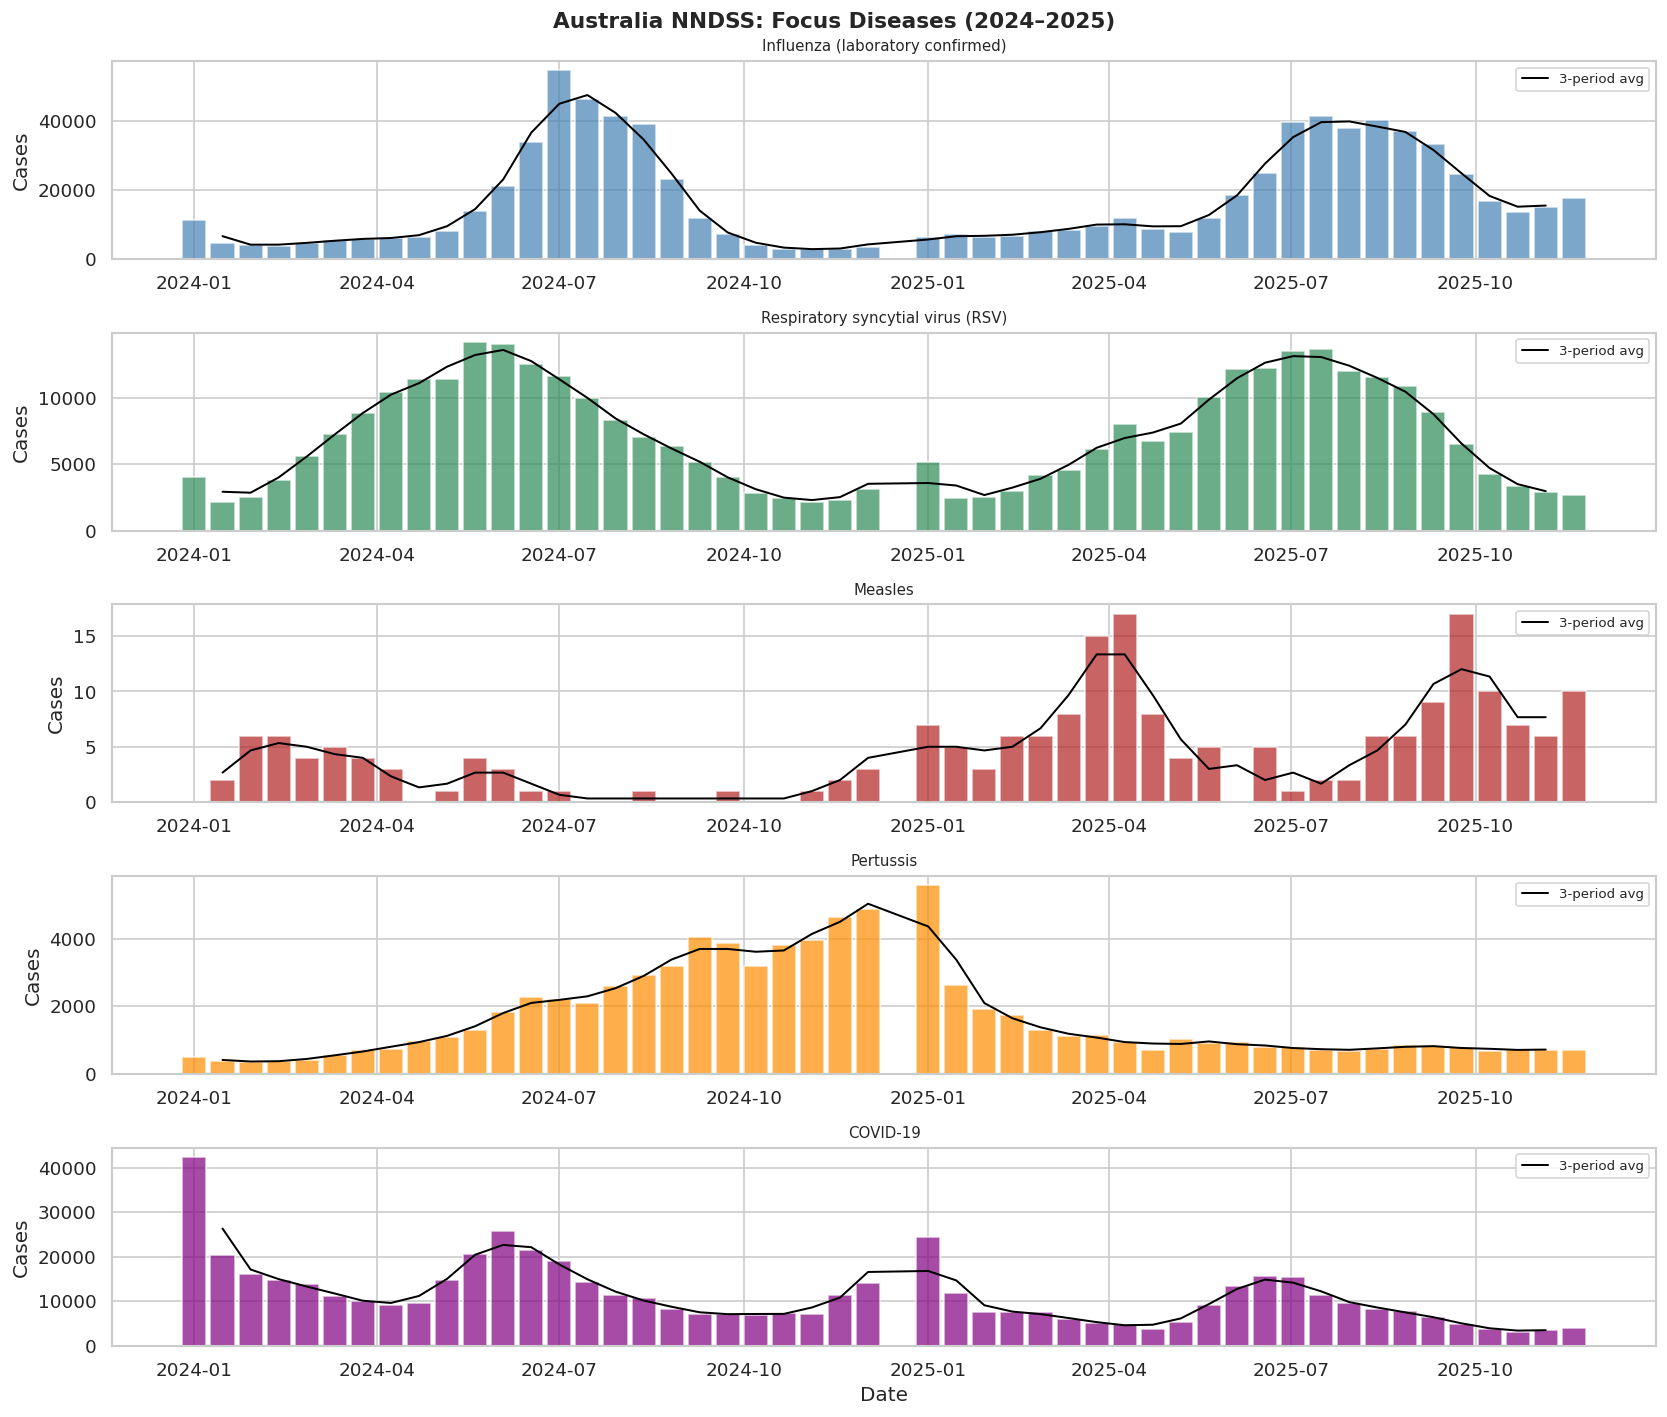

In [ ]:
# EDA: EDA: RSV and Measles

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
fig.suptitle("Australia Disease Surveillance: RSV & Measles (2024–2025)",
             fontsize=13, fontweight='bold')

for ax, wide_df, color, title in zip(
    axes,
    [rsv_wide, msl_wide],
    ['seagreen', 'firebrick'],
    ['Respiratory Syncytial Virus (RSV)', 'Measles']
):
    long = wide_df.melt(id_vars='Disease_Name', var_name='Period', value_name='Cases')
    long['Cases'] = pd.to_numeric(long['Cases'], errors='coerce').fillna(0)
    ax.bar(range(len(long)), long['Cases'], color=color, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Cases per fortnight')

plt.tight_layout()
plt.show()

In [ ]:
# Feature Engineering

def build_features(dates, cases, disease_name):
    """
    Build lag-safe feature matrix from a weekly case time series.
    All features use only data available at or before time t.
    """
    df = pd.DataFrame({'Date': dates, 'Cases': cases}).sort_values('Date').reset_index(drop=True)

    for lag in [1, 2, 3, 4]:
        df[f'lag_{lag}'] = df['Cases'].shift(lag)

    df['roll4_mean'] = df['Cases'].rolling(4).mean()
    df['roll4_std']  = df['Cases'].rolling(4).std().replace(0, np.nan)
    df['roll8_mean'] = df['Cases'].rolling(8).mean()
    df['growth_1w']  = df['Cases'] / df['Cases'].shift(1).replace(0, np.nan)
    df['growth_4w']  = df['Cases'] / df['Cases'].shift(4).replace(0, np.nan)
    df['zscore']     = (df['Cases'] - df['roll8_mean']) / df['roll4_std']

    week_num       = df['Date'].dt.isocalendar().week.astype(int)
    df['week_sin'] = np.sin(2 * np.pi * week_num / 52)
    df['week_cos'] = np.cos(2 * np.pi * week_num / 52)
    df['Disease']  = disease_name

    return df.dropna(subset=['lag_4']).reset_index(drop=True)

features_covid = build_features(aus_covid['Date_reported'], aus_covid['New_cases'], 'COVID-19')
print(f"Feature matrix: {features_covid.shape}")
display(features_covid.head(3))

Feature matrix: (312, 15)


,Date,Cases,lag_1,lag_2,lag_3,lag_4,roll4_mean,roll4_std,roll8_mean,growth_1w,growth_4w,zscore,week_sin,week_cos,Disease
0,2020-02-02,8,4.0,0.0,0.0,0.0,3.00,3.829708,NaN,2.000,NaN,NaN,0.568065,0.822984,COVID-19
1,2020-02-09,3,8.0,4.0,0.0,0.0,3.75,3.304038,NaN,0.375,NaN,NaN,0.663123,0.748511,COVID-19
2,2020-02-16,0,3.0,8.0,4.0,0.0,3.75,3.304038,NaN,0.000,NaN,NaN,0.748511,0.663123,COVID-19


In [ ]:
# Rt Estimation

def estimate_rt(dates, cases, serial_interval_days=5.5, window=4):
    df = pd.DataFrame({'Date': dates, 'Cases': cases}).sort_values('Date').reset_index(drop=True)
    df['Cases'] = df['Cases'].clip(lower=0.1)
    rt_vals = []
    for i in range(len(df)):
        if i < window:
            rt_vals.append(np.nan)
            continue
        window_cases = df['Cases'].iloc[i - window: i + 1].values
        slope        = np.polyfit(np.arange(window + 1), np.log(window_cases + 1), 1)[0]
        period_days  = (df['Date'].iloc[i] - df['Date'].iloc[i - window]).days / window
        r_per_day    = slope / max(period_days, 1)
        rt_vals.append(np.clip(np.exp(r_per_day * serial_interval_days), 0.1, 10.0))
    df['Rt'] = rt_vals
    return df

rt_df          = estimate_rt(aus_covid['Date_reported'], aus_covid['New_cases'])
features_covid = features_covid.merge(rt_df[['Date', 'Rt']], on='Date', how='left')

print(f"Rt range  : {rt_df['Rt'].dropna().min():.2f} → {rt_df['Rt'].dropna().max():.2f}")
print(f"Rt median : {rt_df['Rt'].dropna().median():.2f}")


Rt range  : 0.13 → 7.34
Rt median : 1.00


In [ ]:
# Surge Onset Labeling  ← FIX 1: onset only, not full duration

def label_surge_onset(rt_df, rt_threshold=1.2, min_duration=3):
    """
    surge       = 1 for entire surge duration  (visualization only)
    surge_onset = 1 ONLY for first week of each surge  (prediction target)

    Using onset prevents flat F1 across horizons — predicting
    a specific week is genuinely hard, F1 degrades as horizon grows.
    """
    df = rt_df.copy()
    df['surge']       = 0
    df['surge_onset'] = 0
    run, run_start = 0, None

    for i, row in df.iterrows():
        if pd.notna(row['Rt']) and row['Rt'] > rt_threshold:
            run += 1
            if run_start is None:
                run_start = i
        else:
            if run_start is not None and run >= min_duration:
                df.loc[run_start: i - 1, 'surge'] = 1
                df.loc[run_start, 'surge_onset']   = 1
            run, run_start = 0, None

    if run_start is not None and run >= min_duration:
        df.loc[run_start:, 'surge'] = 1
        df.loc[run_start, 'surge_onset'] = 1

    return df

rt_labeled = label_surge_onset(rt_df, rt_threshold=1.2, min_duration=3)

features_covid = features_covid.drop(columns=['surge', 'surge_onset'], errors='ignore')
features_covid = features_covid.merge(
    rt_labeled[['Date', 'surge', 'surge_onset']], on='Date', how='left'
)
features_covid['surge']       = features_covid['surge'].fillna(0).astype(int)
features_covid['surge_onset'] = features_covid['surge_onset'].fillna(0).astype(int)

print(f"Surge events (onsets) : {features_covid['surge_onset'].sum()}")
print(f"Surge weeks (total)   : {features_covid['surge'].sum()}")
print(f"Normal weeks          : {(features_covid['surge']==0).sum()}")

Surge events (onsets) : 5
Surge weeks (total)   : 32
Normal weeks          : 280


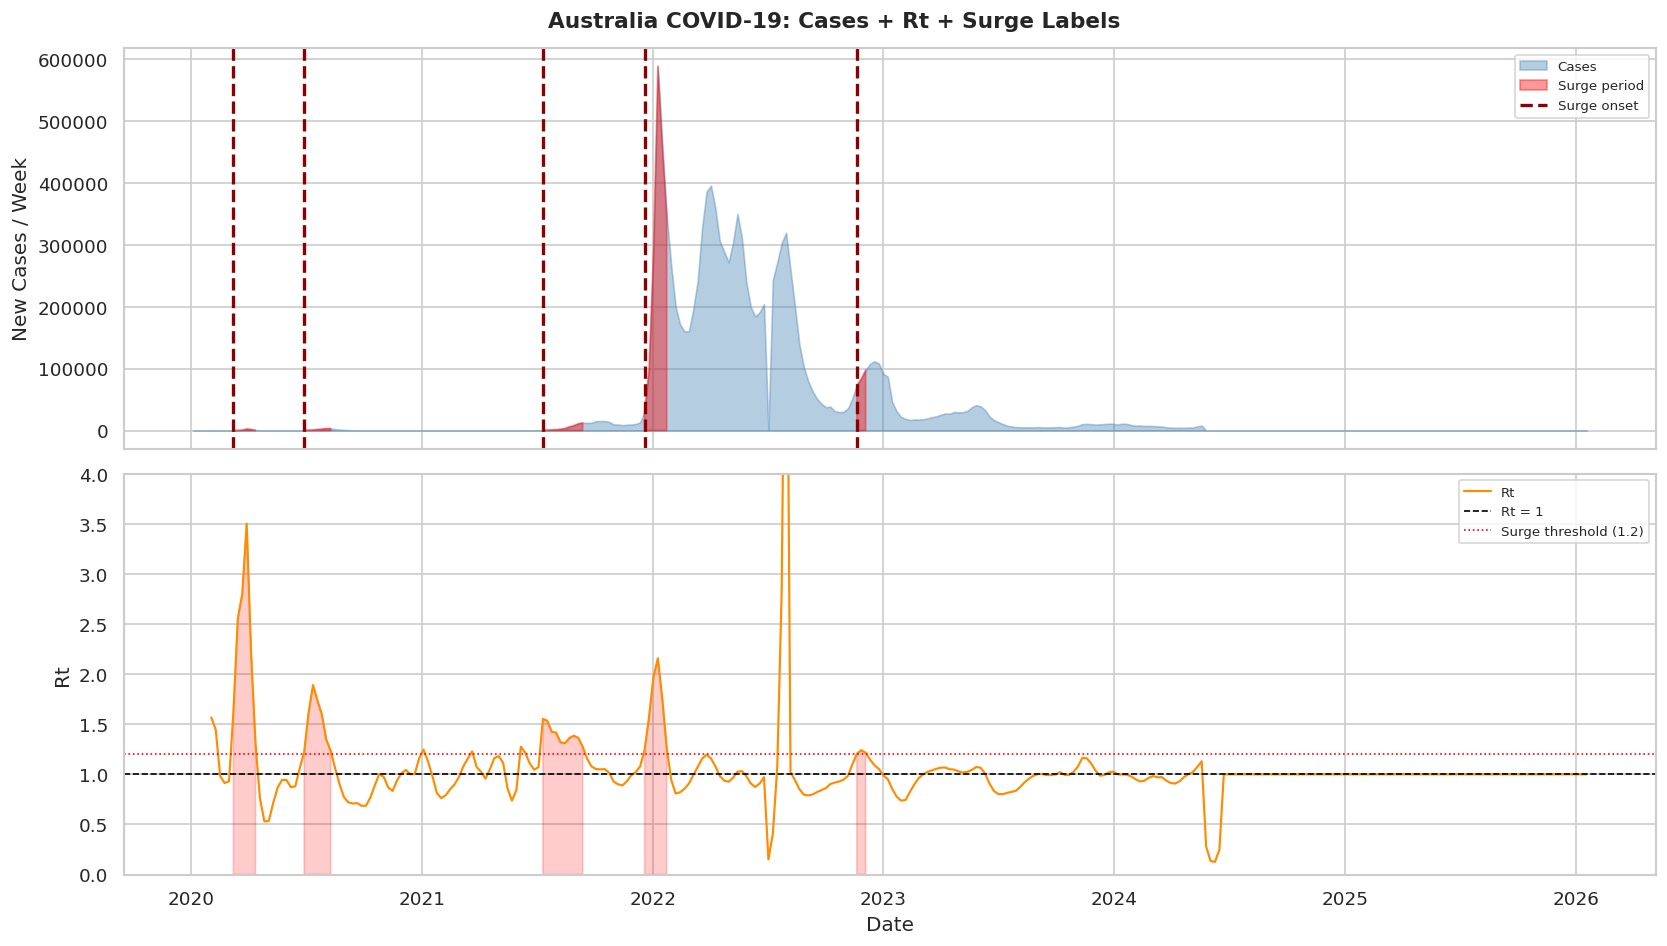

In [ ]:
# Plot: Cases + Rt + Surge Labels

merged = aus_covid[['Date_reported', 'New_cases']].merge(
    rt_labeled[['Date', 'Rt', 'surge', 'surge_onset']],
    left_on='Date_reported', right_on='Date', how='left'
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Australia COVID-19: Cases + Rt + Surge Labels",
             fontsize=13, fontweight='bold')

ax1.fill_between(merged['Date_reported'], merged['New_cases'],
                 alpha=0.4, color='steelblue', label='Cases')
ax1.fill_between(merged['Date_reported'], merged['New_cases'],
                 where=(merged['surge'] == 1), alpha=0.4, color='red', label='Surge period')
onset_dates = merged[merged['surge_onset'] == 1]['Date_reported']
for i, d in enumerate(onset_dates):
    ax1.axvline(d, color='darkred', linewidth=2, linestyle='--',
                label='Surge onset' if i == 0 else '')
ax1.set_ylabel('New Cases / Week')
ax1.legend(fontsize=8)

ax2.plot(merged['Date_reported'], merged['Rt'], color='darkorange', linewidth=1.3, label='Rt')
ax2.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Rt = 1')
ax2.axhline(1.2, color='red', linestyle=':', linewidth=1, label='Surge threshold (1.2)')
ax2.fill_between(merged['Date_reported'], merged['Rt'],
                 where=(merged['surge'] == 1), alpha=0.2, color='red')
ax2.set_ylabel('Rt')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 4)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Save Feature Matrix

features_covid.to_csv(OUTPUT_PATH, index=False)
print(f"   Saved: {OUTPUT_PATH}")
print(f"   Shape   : {features_covid.shape}")
print(f"   Columns : {list(features_covid.columns)}")


   Saved: /workspaces/group-project-inferra/Data/features_covid_aus.csv
   Shape   : (312, 18)
   Columns : ['Date', 'Cases', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'roll4_mean', 'roll4_std', 'roll8_mean', 'growth_1w', 'growth_4w', 'zscore', 'week_sin', 'week_cos', 'Disease', 'Rt', 'surge', 'surge_onset']


In [ ]:
# Prepare Data

FEATURE_COLS = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
    'roll4_mean', 'roll4_std', 'roll8_mean',
    'growth_1w', 'growth_4w',
    'zscore', 'week_sin', 'week_cos', 'Rt'
]
TARGET_COL = 'surge'   # full duration — 32 positive weeks, enough to learn from

model_df = features_covid[FEATURE_COLS + [TARGET_COL, 'Date', 'Cases']].dropna().reset_index(drop=True)
model_df = model_df.sort_values('Date').reset_index(drop=True)

# Holdout test set — last 20%
split_idx = int(len(model_df) * 0.80)
train_df  = model_df.iloc[:split_idx].reset_index(drop=True)
test_df   = model_df.iloc[split_idx:].reset_index(drop=True)

print(f"Total  : {len(model_df)}")
print(f"Train  : {len(train_df)}  {train_df['Date'].min().date()} → {train_df['Date'].max().date()}")
print(f"Test   : {len(test_df)}   {test_df['Date'].min().date()} → {test_df['Date'].max().date()}")
print(f"\nSurge % train : {train_df[TARGET_COL].mean()*100:.1f}%")
print(f"Surge % test  : {test_df[TARGET_COL].mean()*100:.1f}%")

Total  : 219
Train  : 175  2020-03-01 → 2023-07-23
Test   : 44   2023-07-30 → 2024-05-26

Surge % train : 17.7%
Surge % test  : 0.0%


In [ ]:
# Rolling Window CV Function

def rolling_window_cv(df, feature_cols, target_col, horizon=1,
                      n_splits=5, min_train_size=80):
    df = df.copy().sort_values('Date').reset_index(drop=True)
    df['target'] = df[target_col].shift(-horizon)
    df = df.dropna(subset=['target']).reset_index(drop=True)
    n         = len(df)
    fold_size = max((n - min_train_size) // n_splits, 1)
    folds     = []
    for i in range(n_splits):
        train_end = min_train_size + i * fold_size
        test_end  = train_end + fold_size
        if test_end > n:
            break
        folds.append((
            df[feature_cols].iloc[:train_end],
            df['target'].iloc[:train_end].astype(int),
            df[feature_cols].iloc[train_end:test_end],
            df['target'].iloc[train_end:test_end].astype(int),
            df['Date'].iloc[train_end:test_end]
        ))
    print(f"  Folds: {len(folds)} | Test per fold: {fold_size} weeks")
    return folds

print("rolling_window_cv() ready")


rolling_window_cv() ready


In [ ]:
# Define Models

MODELS = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(n_estimators=100, learning_rate=0.05,
                                              max_depth=3, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                                     scale_pos_weight=9, eval_metric='logloss',
                                     random_state=42, verbosity=0))
    ]),
}
print("Models defined:")
for name in MODELS:
    print(f"   • {name}")


Models defined:
   • Logistic Regression
   • Random Forest
   • Gradient Boosting
   • XGBoost


In [ ]:
# Train & Evaluate via CV

HORIZON = 1   # ← change to 2, 4, or 8 to test individually

print(f"{'='*50}")
print(f"  CV TRAINING — SURGE {HORIZON} WEEK(S) AHEAD")
print(f"  (training set only — test set not touched)")
print(f"{'='*50}\n")

cv_results = {}

for model_name, model in MODELS.items():
    folds = rolling_window_cv(train_df, FEATURE_COLS, TARGET_COL, horizon=HORIZON)
    all_preds, all_true, all_probs = [], [], []

    for X_train, y_train, X_val, y_val, _ in folds:
        try:
            sm = SMOTE(random_state=42, k_neighbors=min(2, max(y_train.sum() - 1, 1)))
            X_res, y_res = sm.fit_resample(X_train, y_train)
        except:
            X_res, y_res = X_train, y_train
        model.fit(X_res, y_res)
        all_preds.extend(model.predict(X_val))
        all_probs.extend(model.predict_proba(X_val)[:, 1])
        all_true.extend(y_val)

    all_true  = np.array(all_true)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    cv_results[model_name] = {
        'f1'       : f1_score(all_true, all_preds, zero_division=0),
        'precision': precision_score(all_true, all_preds, zero_division=0),
        'recall'   : recall_score(all_true, all_preds, zero_division=0),
        'auc'      : roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) > 1 else np.nan,
        'y_true': all_true, 'y_pred': all_preds, 'y_prob': all_probs
    }
    m = cv_results[model_name]
    print(f"  {model_name}")
    print(f"    Precision : {m['precision']:.3f}")
    print(f"    Recall    : {m['recall']:.3f}")
    print(f"    F1        : {m['f1']:.3f}")
    print(f"    ROC-AUC   : {m['auc']:.3f}\n")

best_model_name = max(cv_results, key=lambda m: cv_results[m]['auc'])
print(f"Best model: {best_model_name}  AUC={cv_results[best_model_name]['auc']:.3f}")

  CV TRAINING — SURGE 1 WEEK(S) AHEAD
  (training set only — test set not touched)

  Folds: 5 | Test per fold: 18 weeks
  Logistic Regression
    Precision : 0.833
    Recall    : 0.556
    F1        : 0.667
    ROC-AUC   : 0.912

  Folds: 5 | Test per fold: 18 weeks
  Random Forest
    Precision : 0.600
    Recall    : 0.667
    F1        : 0.632
    ROC-AUC   : 0.932

  Folds: 5 | Test per fold: 18 weeks
  Gradient Boosting
    Precision : 0.857
    Recall    : 0.667
    F1        : 0.750
    ROC-AUC   : 0.774

  Folds: 5 | Test per fold: 18 weeks
  XGBoost
    Precision : 0.857
    Recall    : 0.667
    F1        : 0.750
    ROC-AUC   : 0.859

Best model: Random Forest  AUC=0.932


In [ ]:
# Final Evaluation on Holdout Test Set

best_model = MODELS[best_model_name]

# Retrain on full training set
X_train_full = train_df[FEATURE_COLS]
y_train_full = train_df[TARGET_COL].shift(-HORIZON).dropna().astype(int)
X_train_full = X_train_full.iloc[:len(y_train_full)]

try:
    sm = SMOTE(random_state=42, k_neighbors=min(2, max(y_train_full.sum() - 1, 1)))
    X_res, y_res = sm.fit_resample(X_train_full, y_train_full)
except:
    X_res, y_res = X_train_full, y_train_full

best_model.fit(X_res, y_res)

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL].shift(-HORIZON).dropna().astype(int)
X_test = X_test.iloc[:len(y_test)]

y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

print(f"{'='*50}")
print(f"  FINAL TEST SET — {best_model_name}")
print(f"  Horizon: {HORIZON} week(s) ahead")
print(f"{'='*50}")
print(f"  Precision : {precision_score(y_test, y_pred_test, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_test, y_pred_test, zero_division=0):.3f}")
print(f"  F1        : {f1_score(y_test, y_pred_test, zero_division=0):.3f}")
try:
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_test):.3f}")
except:
    print(f"  ROC-AUC   : N/A (no positive samples in test set)")




  FINAL TEST SET — Random Forest
  Horizon: 1 week(s) ahead
  Precision : 0.000
  Recall    : 0.000
  F1        : 0.000
  ROC-AUC   : nan


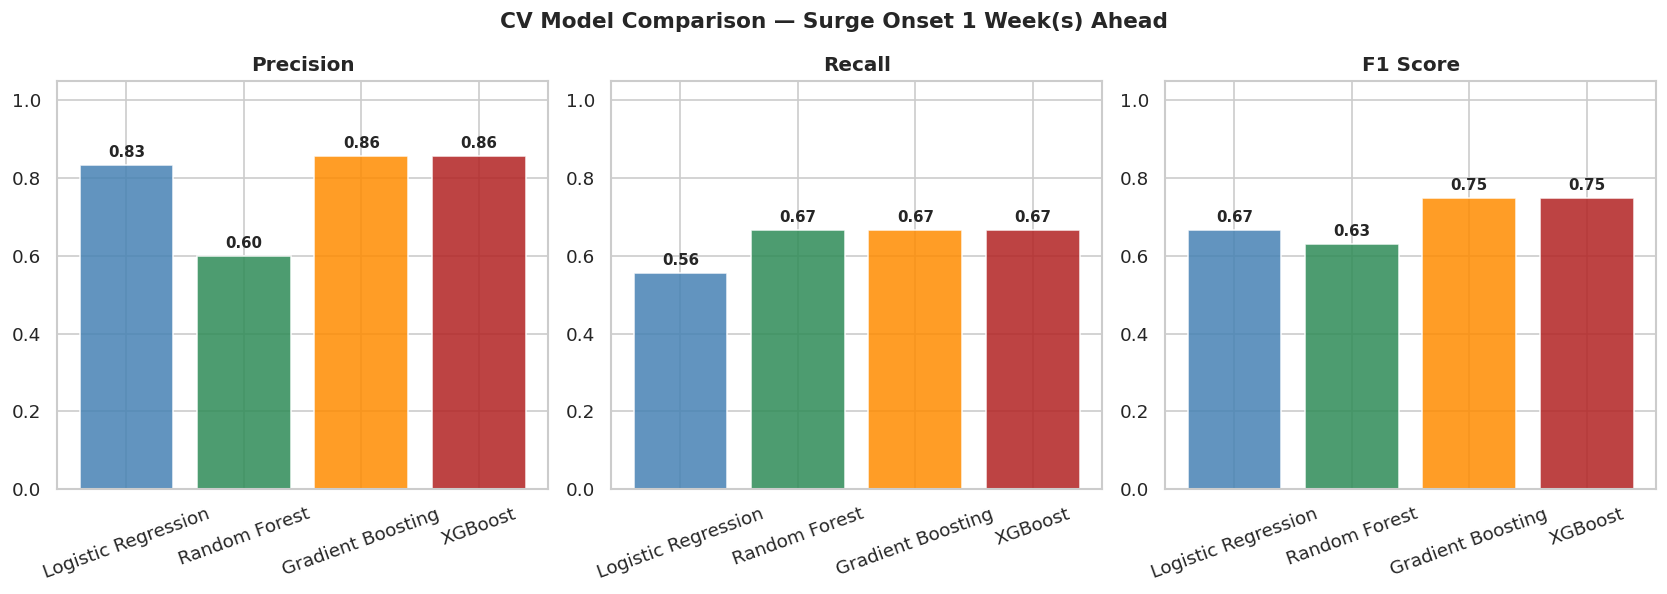

In [ ]:
# Plot: Model Comparison Bar Chart

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(f"CV Model Comparison — Surge Onset {HORIZON} Week(s) Ahead",
             fontsize=13, fontweight='bold')

metrics = ['precision', 'recall', 'f1']
titles  = ['Precision', 'Recall', 'F1 Score']
colors  = ['steelblue', 'seagreen', 'darkorange', 'firebrick']
names   = list(cv_results.keys())

for ax, metric, title in zip(axes, metrics, titles):
    values = [cv_results[m][metric] for m in names]
    bars   = ax.bar(names, values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


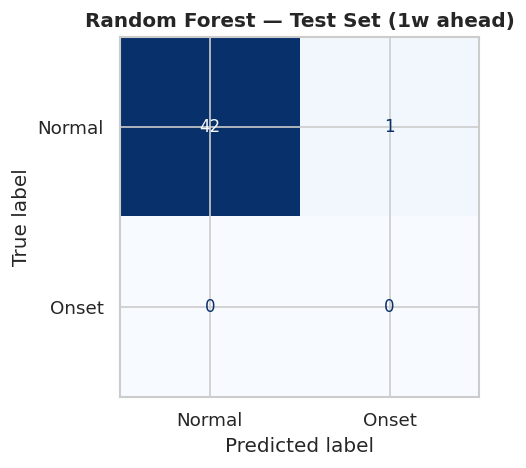

TN (top-left)  = correctly said NO onset  ✅
FP (top-right) = false alarm               ⚠️
FN (bot-left)  = missed a surge onset      🚨  ← keep LOW
TP (bot-right) = correctly caught onset    ✅


In [ ]:
# Plot: Confusion Matrix (Test Set)

fig, ax = plt.subplots(figsize=(5, 4))
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Onset'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"{best_model_name} — Test Set ({HORIZON}w ahead)", fontweight='bold')
plt.tight_layout()
plt.show()

print("TN (top-left)  = correctly said NO onset  ✅")
print("FP (top-right) = false alarm               ⚠️")
print("FN (bot-left)  = missed a surge onset      🚨  ← keep LOW")
print("TP (bot-right) = correctly caught onset    ✅")




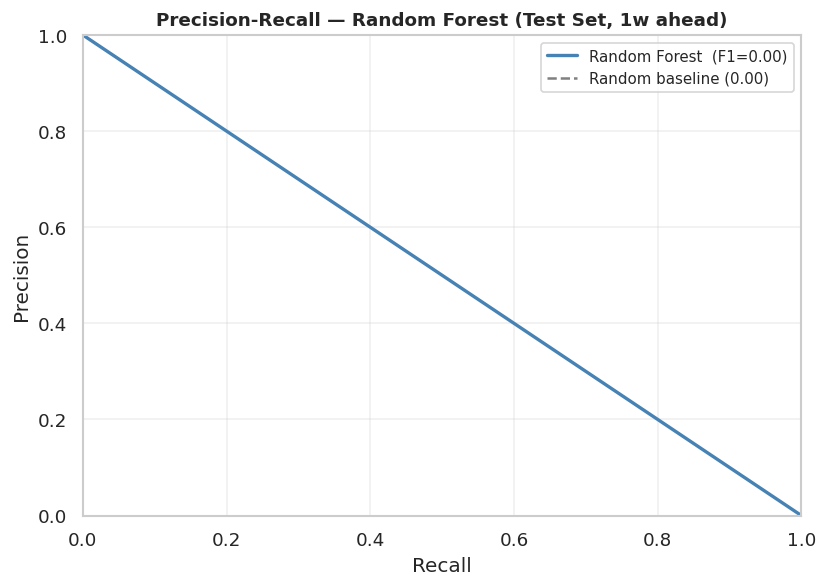

In [ ]:
# Plot: Precision-Recall Curve (Test Set)

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title(f"Precision-Recall — {best_model_name} (Test Set, {HORIZON}w ahead)",
             fontsize=11, fontweight='bold')

prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
ax.plot(rec, prec, color='steelblue', linewidth=2,
        label=f"{best_model_name}  (F1={f1_score(y_test, y_pred_test, zero_division=0):.2f})")
ax.axhline(y_test.mean(), color='gray', linestyle='--',
           label=f'Random baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


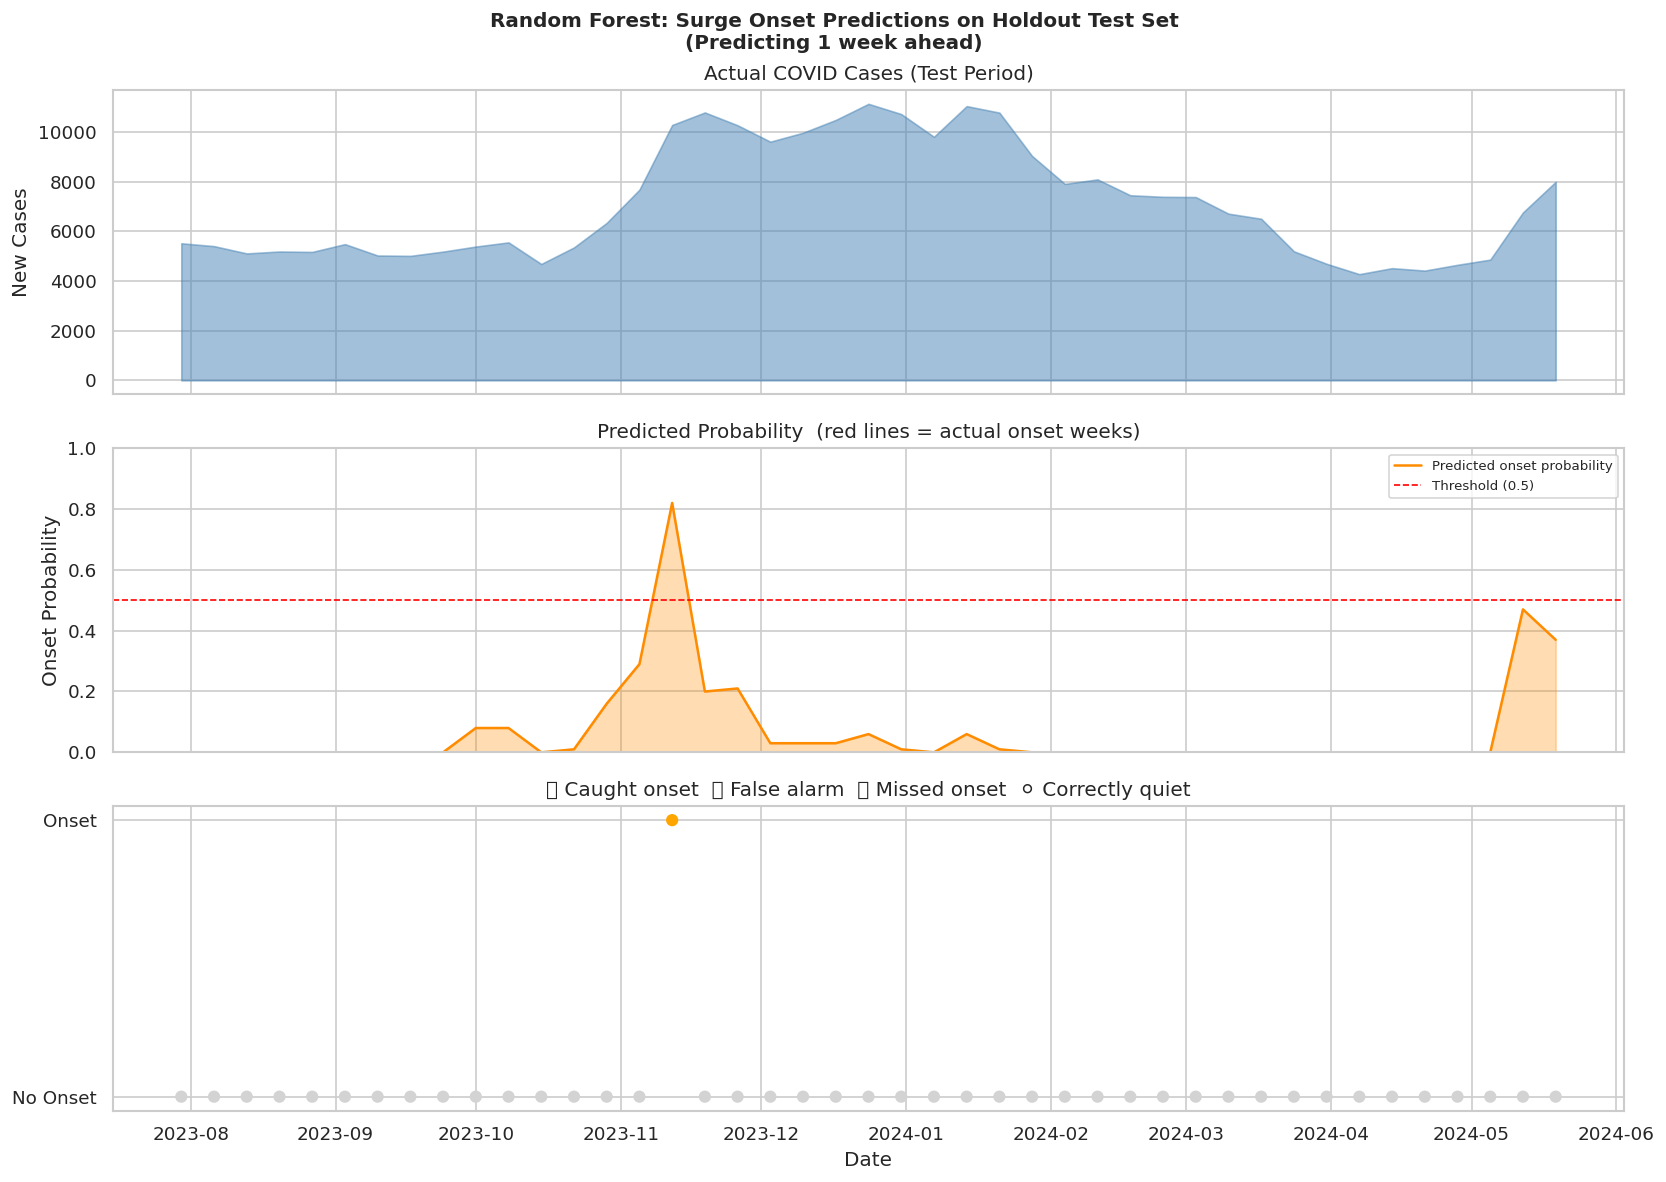

In [ ]:
# Plot: Predictions on Timeline (Test Set)

dates_test = test_df['Date'].iloc[:len(y_test)]
cases_test = test_df['Cases'].iloc[:len(y_test)]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"{best_model_name}: Surge Onset Predictions on Holdout Test Set\n"
             f"(Predicting {HORIZON} week ahead)",
             fontsize=12, fontweight='bold')

ax1.fill_between(dates_test, cases_test, alpha=0.5, color='steelblue')
ax1.set_ylabel('New Cases')
ax1.set_title('Actual COVID Cases (Test Period)')

ax2.plot(dates_test, y_prob_test, color='darkorange', linewidth=1.5,
         label='Predicted onset probability')
ax2.fill_between(dates_test, y_prob_test, alpha=0.3, color='darkorange')
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Threshold (0.5)')
for date, actual in zip(dates_test, y_test):
    if actual == 1:
        ax2.axvline(date, color='red', linewidth=2, alpha=0.8)
ax2.set_ylabel('Onset Probability')
ax2.set_ylim(0, 1)
ax2.set_title('Predicted Probability  (red lines = actual onset weeks)')
ax2.legend(fontsize=8)

dot_colors = []
for pred, actual in zip(y_pred_test, y_test):
    if   pred == 1 and actual == 1: dot_colors.append('green')
    elif pred == 0 and actual == 0: dot_colors.append('lightgray')
    elif pred == 1 and actual == 0: dot_colors.append('orange')
    else:                            dot_colors.append('red')

ax3.scatter(dates_test, y_pred_test, c=dot_colors, s=40, zorder=5)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['No Onset', 'Onset'])
ax3.set_xlabel('Date')
ax3.set_title('🟢 Caught onset  🟠 False alarm  🔴 Missed onset  ⚪ Correctly quiet')

plt.tight_layout()
plt.show()




In [ ]:
# All Models Across All Horizons

HORIZONS = [1, 2, 3, 4, 6, 8]
horizon_results = {name: [] for name in MODELS}

print("Running all models across all horizons (CV on train only)...")
for h in HORIZONS:
    print(f"  Horizon = {h} weeks ... ", end='')
    for model_name, model in MODELS.items():
        folds_h = rolling_window_cv(train_df, FEATURE_COLS, TARGET_COL, horizon=h)
        all_p, all_t = [], []
        for X_train, y_train, X_val, y_val, _ in folds_h:
            try:
                sm = SMOTE(random_state=42, k_neighbors=min(2, max(y_train.sum() - 1, 1)))
                X_r, y_r = sm.fit_resample(X_train, y_train)
            except:
                X_r, y_r = X_train, y_train
            model.fit(X_r, y_r)
            all_p.extend(model.predict(X_val))
            all_t.extend(y_val)
        try:
            horizon_results[model_name].append(roc_auc_score(all_t, all_p))
        except:
            horizon_results[model_name].append(np.nan)
    print("✓")

summary = pd.DataFrame(horizon_results, index=HORIZONS)
summary.index.name = 'Horizon (weeks ahead)'
print("\nROC-AUC Scores by Horizon:")
display(summary.round(3))

Running all models across all horizons (CV on train only)...
  Horizon = 1 weeks ...   Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
✓
  Horizon = 2 weeks ...   Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
✓
  Horizon = 3 weeks ...   Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
✓
  Horizon = 4 weeks ...   Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
  Folds: 5 | Test per fold: 18 weeks
✓
  Horizon = 6 weeks ...   Folds: 5 | Test per fold: 17 weeks
  Folds: 5 | Test per fold: 17 weeks
  Folds: 5 | Test per fold: 17 weeks
  Folds: 5 | Test per fold: 17 weeks
✓
  Horizon = 8 weeks ...   Folds: 5 | Test per fold: 17 weeks
  Folds:

,Logistic Regression,Random Forest,Gradient Boosting,XGBoost
Horizon (weeks ahead),,,,
1,0.772,0.809,0.827,0.827
2,0.562,0.710,0.691,0.722
3,0.494,0.475,0.432,0.531
4,0.395,0.475,0.426,0.340
6,0.382,0.500,0.480,0.434
8,0.391,0.408,0.434,0.375


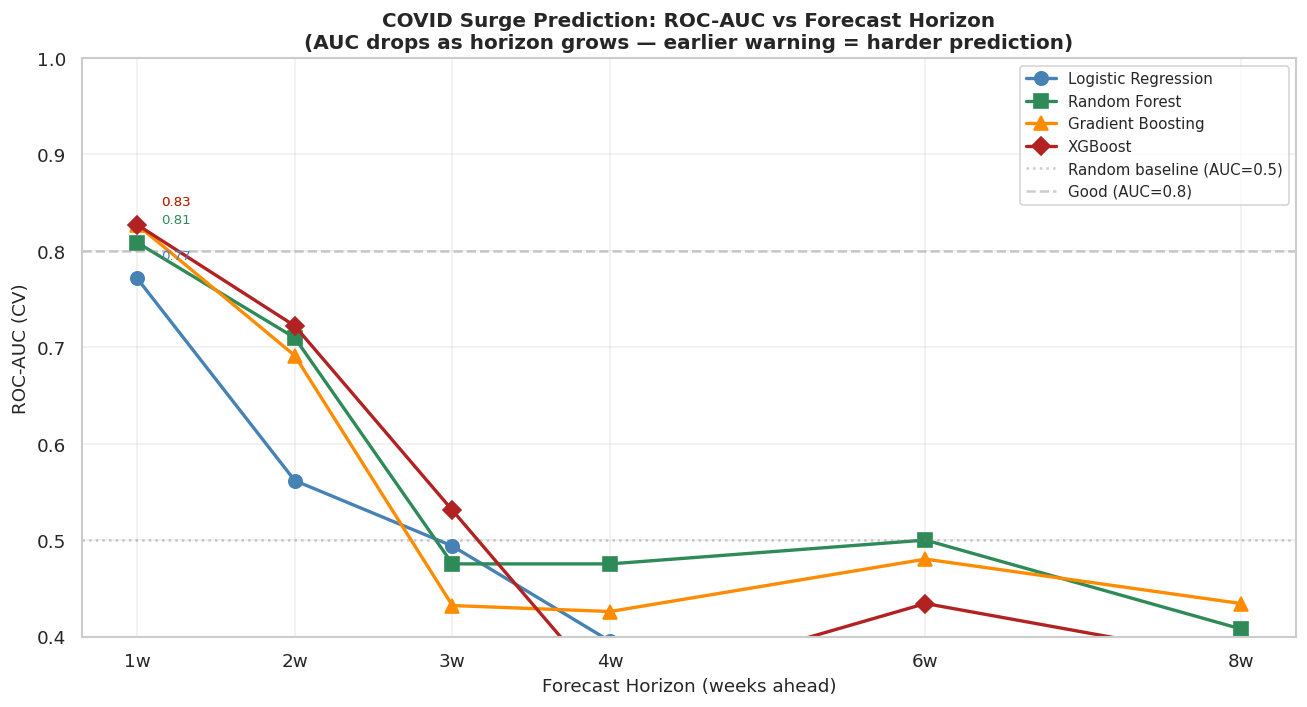


SUMMARY:
Model                         1w     2w     4w     8w
--------------------------------------------------
  Logistic Regression      0.772  0.562  0.395  0.391
  Random Forest            0.809  0.710  0.475  0.408
  Gradient Boosting        0.827  0.691  0.426  0.434
  XGBoost                  0.827  0.722  0.340  0.375


In [ ]:
# Plot: ROC-AUC vs Horizon (Main Result)

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_title("COVID Surge Prediction: ROC-AUC vs Forecast Horizon\n"
             "(AUC drops as horizon grows — earlier warning = harder prediction)",
             fontsize=12, fontweight='bold')

colors_h = ['steelblue', 'seagreen', 'darkorange', 'firebrick']
markers  = ['o', 's', '^', 'D']

for (model_name, auc_scores), color, marker in zip(horizon_results.items(), colors_h, markers):
    ax.plot(HORIZONS, auc_scores, marker=marker, color=color,
            linewidth=2, markersize=8, label=model_name)
    best_idx = int(np.nanargmax(auc_scores))
    ax.annotate(f"{auc_scores[best_idx]:.2f}",
                xy=(HORIZONS[best_idx], auc_scores[best_idx]),
                xytext=(HORIZONS[best_idx] + 0.15, auc_scores[best_idx] + 0.02),
                fontsize=8, color=color)

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4, label='Random baseline (AUC=0.5)')
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.4, label='Good (AUC=0.8)')
ax.set_xlabel('Forecast Horizon (weeks ahead)', fontsize=11)
ax.set_ylabel('ROC-AUC (CV)', fontsize=11)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([f'{h}w' for h in HORIZONS])
ax.set_ylim(0.4, 1.0)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSUMMARY:")
print(f"{'Model':<25}  {'1w':>5}  {'2w':>5}  {'4w':>5}  {'8w':>5}")
print("-" * 50)
for model_name, auc_scores in horizon_results.items():
    vals = [auc_scores[HORIZONS.index(h)] for h in [1, 2, 4, 8]]
    print(f"  {model_name:<23}  {vals[0]:>5.3f}  {vals[1]:>5.3f}  {vals[2]:>5.3f}  {vals[3]:>5.3f}")

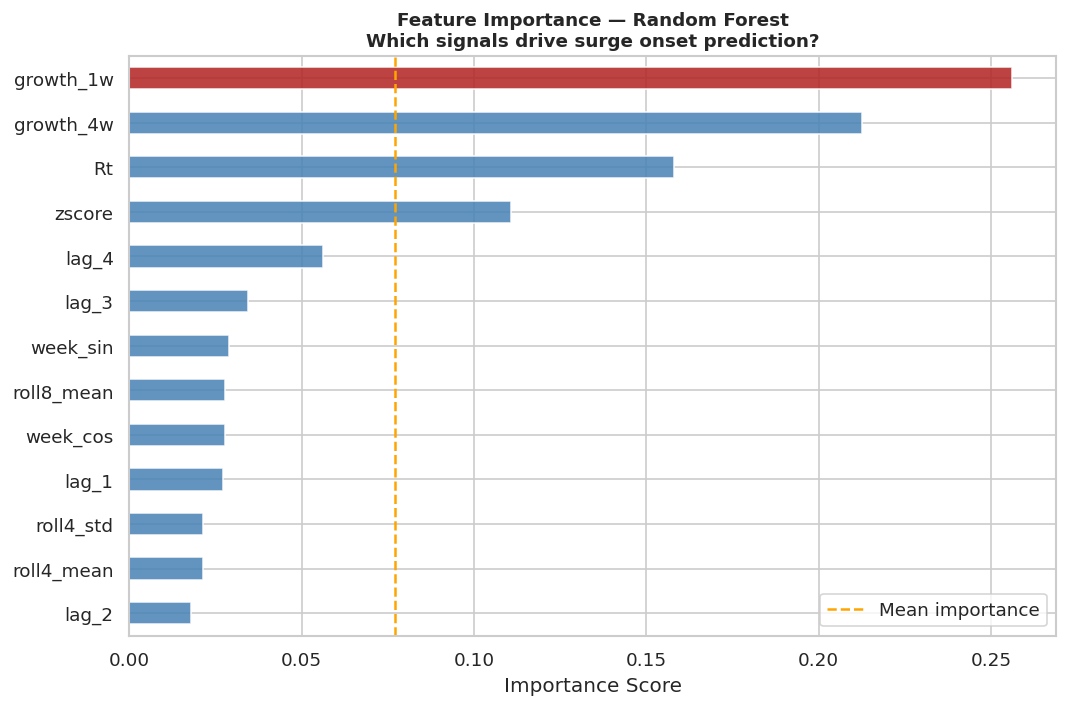


Top 3 features:
  growth_1w       : 0.2561
  growth_4w       : 0.2124
  Rt              : 0.1582


In [ ]:
# Feature Importance

best_pipe = MODELS[best_model_name]
best_pipe.fit(X_res, y_res)
clf = best_pipe.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_[0])
else:
    importances = np.ones(len(FEATURE_COLS))

feat_imp   = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
colors_imp = ['firebrick' if v == feat_imp.max() else 'steelblue' for v in feat_imp.values]

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind='barh', ax=ax, color=colors_imp, alpha=0.85, edgecolor='white')
ax.axvline(feat_imp.mean(), color='orange', linestyle='--', label='Mean importance')
ax.set_title(f"Feature Importance — {best_model_name}\n"
             f"Which signals drive surge onset prediction?",
             fontsize=11, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nTop 3 features:")
for feat, val in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"  {feat:<15} : {val:.4f}")